# Team FSH CV Pipeline

## To-Do
- upload/select video file and turn it into a folder of images
- choose points to track
    - display the 0th frame and allow user to click on specific spots
    - save coordinates of clicked locations for use
    - assign each point to a specific object, and whether the point is inclusion or exclusion
- show results of selected points
- run training
- produce a video output

- mark down frames where number of objects detected drops

> jupyter notebook --no-browser --port=8889 --ip=0.0.0.0

### Configuration

**Global Variables**

In [1]:
INPUT_VID_PATH = "../jason/circle002_30s_1.avi"
JPEGS_DIR_PATH = "../jpegs_dir/" # Must be created ahead before running later code blocks
OUTPUT_PATH = "../output" # Must be created ahead of time

**Model Selection**

In [2]:
sam2_checkpoint = "../../programs/sam2/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

### Imports

In [3]:
%matplotlib widget

In [4]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from PIL import Image
import cv2
from tqdm import tqdm

### Hardware Checks

**Cluster GPU**

The graphic below should show *NVIDIA RTX A4000* or *NVIDIA RTX A5000*. If not, run one of the following commands in the terminal to request a session from the cluster.

> srun --pty --ntasks=4 --gres gpu:rtxa4000:1 --qos scavenger --account scavenger --partition scavenger --mem 20G --time 48:00:00 bash
>
or
>
> srun --pty --ntasks=4 --gres gpu:rtxa5000:1 --qos scavenger --account scavenger --partition scavenger --mem 20G --time 48:00:00 bash

In [5]:
!nvidia-smi

Tue Jul 29 21:42:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.153.02             Driver Version: 570.153.02     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000               Off |   00000000:C1:00.0 Off |                  Off |
| 41%   33C    P8             17W /  140W |       1MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**PyTorch Settings**

If a GPU has been requested, the following code block should output "cuda". Otherwise, it may output "mps" for Mac chips, or "cpu" for other CPUs. Using a GPU is recommended for timely predictions.

In [6]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.float16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


### Data Preparation

**Video to JPEG Conversion**

When dealing with video data, the video needs to be converted into a folder of jpegs in order for SAM 2 to process it. Each jpeg in the folder represents a single frame in the original video.

In [7]:
!module load ffmpeg
!ffmpeg -i {INPUT_VID_PATH} -q:v 2 -start_number 0 {JPEGS_DIR_PATH}/'%05d.jpg'

ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/opt/local/stow/ffmpeg-7.1 --enable-shared --enable-gpl --enable-libass --enable-libfdk-aac --enable-libopus --enable-libtheora --enable-libvorbis --enable-libvpx --enable-libx264 --enable-nonfree --enable-rpath --enable-libx265 --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libfribidi --enable-ffnvcodec
  libavutil      59. 39.100 / 59. 39.100
  libavcodec     61. 19.100 / 61. 19.100
  libavformat    61.  7.100 / 61.  7.100
  libavdevice    61.  3.100 / 61.  3.100
  libavfilter    10.  4.100 / 10.  4.100
  libswscale      8.  3.100 /  8.  3.100
  libswresample   5.  3.100 /  5.  3.100
  libpostproc    58.  3.100 / 58.  3.100
[in#0 @ 0x256a280] Error opening input: No such file or directory
Error opening input file ../jason/circle002_30s_1.avi.
Error opening input files: No such file or directory


**Scanning JPEG Directory**

In [8]:
frame_names = [
    p for p in os.listdir(JPEGS_DIR_PATH)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

### SAM 2 Stuff

**Helper Functions**

In [9]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

**Initializing the Predictor**

In [10]:
from sam2.build_sam import build_sam2_video_predictor
predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)
inference_state = predictor.init_state(
    video_path=JPEGS_DIR_PATH,
    offload_video_to_cpu=True,
    offload_state_to_cpu=False,
    )

frame loading (JPEG): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:21<00:00, 37.42it/s]


In [11]:
predictor.reset_state(inference_state)

**UI Helper Functions**

In [12]:
def add_point(frame, obj, points_arr, labels_arr, display):
    points = np.array(points_arr, dtype=np.float32)
    labels = np.array(labels_arr, np.int32)
    # prompts[obj] = points, labels
    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state = inference_state,
        frame_idx = frame,
        obj_id = obj,
        points = points,
        labels = labels,
    )

    if display:
        plt.figure(figsize = (9, 6))
        plt.title(f"frame {frame}")
        plt.imshow(Image.open(os.path.join(JPEGS_DIR_PATH, frame_names[frame])))
        show_points(points, labels, plt.gca())
        for i, out_obj_id in enumerate(out_obj_ids):
            # show_points(*prompts[out_obj_id], plt.gca())
            show_mask((out_mask_logits[i] > 0.0).cpu().numpy(), plt.gca(), obj_id = out_obj_id)
        plt.savefig(f"{OUTPUT_PATH}/point_add.png")
        plt.close()

def propagate(vis_frame_stride, display):
    # run propagation throughout the video and collect the results in a dict
    video_segments = {}  # video_segments contains the per-frame segmentation results
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }

    # render the segmentation results every few frames
    plt.close("all")
    if display:
        for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
            plt.figure(figsize=(6, 4))
            plt.title(f"frame {out_frame_idx}")
            # plt.axis("off")
            plt.imshow(Image.open(os.path.join(JPEGS_DIR_PATH, frame_names[out_frame_idx])))
            for out_obj_id, out_mask in video_segments[out_frame_idx].items():
                show_mask(out_mask, plt.gca(), obj_id=out_obj_id)
            
            out_frame_idx = f"{out_frame_idx:05d}"
            plt.savefig(f"{OUTPUT_PATH}/propagate_{out_frame_idx}.png")
            plt.close()

    return video_segments

### Running Predictions

The first codeblock contains the necissary functions.  
The second codeblock will create an interactive window, follow the instructions and select one point per fish  
Finally run the third codeblock to generate masks

In [13]:
class InteractiveVideoLabeler:
    def __init__(self, frame, sam2_predictor=None):
        self.frame = frame
        self.sam2_predictor = predictor
        self.points = []
        self.labels = []
        self.fig = None
        self.ax = None
        
    def onclick(self, event):
        """Handle mouse click events"""
        if event.inaxes != self.ax:
            return
        
        if event.button == 1:  # Left click - positive point
            self.add_point(event.xdata, event.ydata, label=1)
        elif event.button == 3:  # Right click - negative point
            self.add_point(event.xdata, event.ydata, label=0)
    
    def add_point(self, x, y, label):
        """Add a point and update the visualization"""
        self.points.append([x, y])
        self.labels.append(label)
        
        # Visual feedback
        color = 'green' if label == 1 else 'red'
        marker = 'o' if label == 1 else 'x'
        
        self.ax.plot(x, y, marker=marker, color=color, markersize=10, markeredgewidth=2)
        
        print(f"Added {'positive' if label == 1 else 'negative'} point at ({x:.1f}, {y:.1f})")
        
        # Redraw the plot
        self.fig.canvas.draw()
    
    def show_interactive_frame(self, figsize=(12, 8)):
        """Display the frame with interactive clicking enabled"""
        self.fig, self.ax = plt.subplots(figsize=figsize)
        
        # Display the frame
        self.ax.imshow(self.frame)
        self.ax.set_title("Click to add points: Left click = Positive (green), Right click = Negative (red)")
        self.ax.axis('on')  # Keep axes for coordinate reference
        
        # Connect the click event
        self.fig.canvas.mpl_connect('button_press_event', self.onclick)
        
        plt.tight_layout()
        
        # For Jupyter notebooks, we need to display and return immediately
        # The user will interact with the plot, then call get_points_for_sam2() separately
        plt.show()
        
        print("Plot is now interactive! Click on the image to add points.")
        print("When you're done clicking, run: labeler.get_points_for_sam2()")
        
        # Don't return points immediately - they need to be collected separately
        return None, None
    
    def get_points_for_sam2(self):
        """Return points and labels in SAM2-compatible format"""
        if len(self.points) == 0:
            return None, None
        return np.array(self.points), np.array(self.labels)

def interactive_labeling_example():
    """Example of how to use the interactive labeler in Jupyter"""
    
    # Load your frame
    firstframe = os.path.join(JPEGS_DIR_PATH, frame_names[0])
    frame = cv2.imread(firstframe)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Create the interactive labeler
    labeler = InteractiveVideoLabeler(frame)
    
    # Show interactive frame (this returns immediately in Jupyter)
    labeler.show_interactive_frame()
    
    # Return the labeler object so user can get points later
    return labeler

def process_collected_points(labeler):
    """Call this after you've finished clicking on the interactive plot"""
    points, labels = labeler.get_points_for_sam2()
    
    # Check if we got any points
    if points is not None and len(points) > 0:
        print(f"Got {len(points)} points from interactive labeling")
        
        # Add each point to your SAM2 tracker

        obj_number = 0
        disp = True

        for i, (point, label) in enumerate(zip(points, labels)):
            point_coords = [[int(point[0]), int(point[1])]]
            point_label = [int(label)]
            
            print(f"Adding point {i+1}: {point_coords} with label {point_label}")
            add_point(0, obj_number, point_coords, point_label, disp)  # All to object 1
    
    else:
        print("No points were selected")

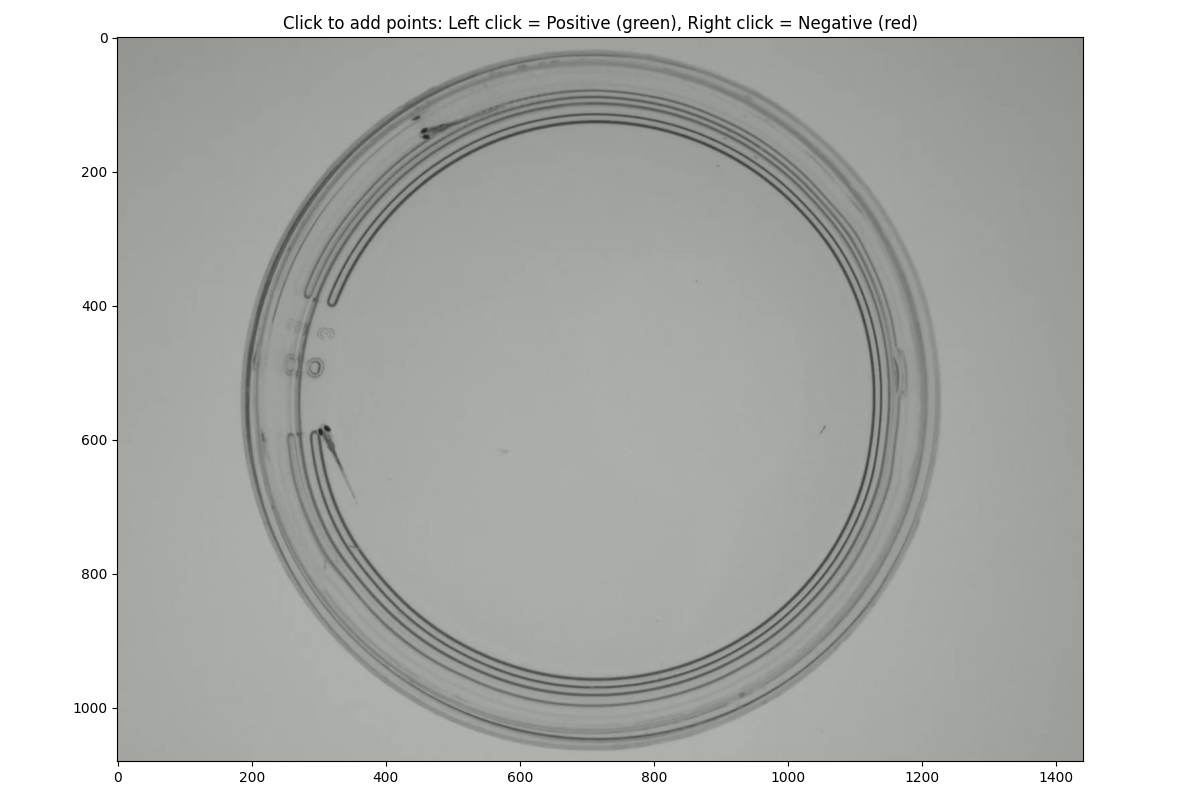

Plot is now interactive! Click on the image to add points.
When you're done clicking, run: labeler.get_points_for_sam2()


In [14]:
# add the points using interactive selection
if __name__ == "__main__":
    disp = True
    labeler = interactive_labeling_example()

In [16]:
if __name__ == "__main__":
    process_collected_points(labeler)
    vid_seg = propagate(40, disp)

Got 5 points from interactive labeling
Adding point 1: [[309, 588]] with label [1]


/fs/vulcan-projects/fsh_track/programs/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/fs/vulcan-projects/fsh_track/programs/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Adding point 2: [[459, 145]] with label [1]
Adding point 3: [[358, 628]] with label [0]
Adding point 4: [[509, 172]] with label [0]
Adding point 5: [[294, 631]] with label [0]


propagate in video: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [01:31<00:00,  8.74it/s]


**Creating Output Video**

In [17]:
# btw you can use ffprobe to get the frame rate of the input video
# ffprobe -v 0 -of compact=p=0 -select_streams 0 -show_entries stream=r_frame_rate input.mp4

frames = 800
time = 30
fps = frames / time

In [18]:
!ffmpeg -framerate {fps} -start_number 0 -i {OUTPUT_PATH}/"propagate_%05d.png" -c:v libx264 -pix_fmt yuv420p output.mp4

ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (GCC)
  configuration: --prefix=/opt/local/stow/ffmpeg-7.1 --enable-shared --enable-gpl --enable-libass --enable-libfdk-aac --enable-libopus --enable-libtheora --enable-libvorbis --enable-libvpx --enable-libx264 --enable-nonfree --enable-rpath --enable-libx265 --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libfribidi --enable-ffnvcodec
  libavutil      59. 39.100 / 59. 39.100
  libavcodec     61. 19.100 / 61. 19.100
  libavformat    61.  7.100 / 61.  7.100
  libavdevice    61.  3.100 / 61.  3.100
  libavfilter    10.  4.100 / 10.  4.100
  libswscale      8.  3.100 /  8.  3.100
  libswresample   5.  3.100 /  5.  3.100
  libpostproc    58.  3.100 / 58.  3.100
Input #0, image2, from '../output/propagate_%05d.png':
  Duration: 00:00:00.04, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png, rgba(pc, gbr/unknown/unknown), 600x400 [SAR 3937:3937 DAR 3:2], 26.67 fps, 26.67 tbr, 

In [19]:
# Outputs a black and white video of the masks


# Parameters
    # Change this to the path where you want to save the video
OUTPUT_PATH = "../output/output.mp4"

    # Use 
    # ffprobe -v 0 -of compact=p=0 -select_streams 0 -show_entries stream=r_frame_rate input.mp4
    # to get the frame rate of the input video
fps = 35  # frames per second

# Get frame size from one mask
first_frame = next(iter(vid_seg))
first_obj = next(iter(vid_seg[first_frame]))
mask_shape = vid_seg[first_frame][first_obj].shape[-2:]
height, width = mask_shape

# Create a VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height), isColor=True)

# Iterate over frames in order
for frame_idx in sorted(vid_seg.keys()):
    # Combine masks for all objects (e.g., OR them together)
    combined_mask = np.zeros((height, width), dtype=np.uint8)
    for obj_id, mask in vid_seg[frame_idx].items(): # Can change this to iterate over specific object id(s)
        # mask shape: (1, H, W) or (H, W)
        mask_bin = mask.squeeze().astype(np.uint8) * 255
        combined_mask = np.maximum(combined_mask, mask_bin)
    # Convert to 3-channel image for video
    mask_rgb = cv2.cvtColor(combined_mask, cv2.COLOR_GRAY2BGR)
    out.write(mask_rgb)

out.release()
print(f"Video saved to {OUTPUT_PATH}")

Video saved to ../output/output.mp4


In [20]:
# Outputs a color video with masks overlaid on the original frames

# Get frame size and fps from previous variables
frame_size = (width, height)

# Create VideoWriter for the final video
final_out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, frame_size, isColor=True)

# Define a list of distinct colors for up to 10 objects (B, G, R)
object_colors = [
    (0, 255, 0),      # Green
    (0, 0, 255),      # Red
    (255, 0, 0),      # Blue
    (0, 255, 255),    # Yellow
    (255, 0, 255),    # Magenta
    (255, 255, 0),    # Cyan
    (128, 128, 0),    # Olive
    (128, 0, 128),    # Purple
    (0, 128, 128),    # Teal
    (255, 128, 0),    # Orange
]

# Alpha blending factor for mask overlay
alpha = 0.4

for frame_idx in tqdm(sorted(vid_seg.keys()), desc="Creating final video"):
    # Load original frame
    frame_path = os.path.join(JPEGS_DIR_PATH, frame_names[frame_idx])
    frame = cv2.imread(frame_path)
    if frame is None:
        continue

    # Create a color mask for all objects
    color_mask = np.zeros_like(frame)
    for i, (obj_id, mask) in enumerate(vid_seg[frame_idx].items()):
        mask_bin = mask.squeeze().astype(np.uint8)
        color = object_colors[i % len(object_colors)]
        color_mask[mask_bin > 0] = color

    # Blend mask with original frame
    blended = cv2.addWeighted(frame, 1 - alpha, color_mask, alpha, 0)

    final_out.write(blended)

final_out.release()
print(f"Final video saved to {OUTPUT_PATH}")

Creating final video: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:07<00:00, 112.68it/s]

Final video saved to ../output/output.mp4
